<a href="https://colab.research.google.com/github/Verdexte12/Curso_Alura/blob/main/Limpieza_y_tratamiento_de_datos_con_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1.1 - Exploración inicial

In [ ]:
import pandas as pd
df= pd.read_json("datos_telecom.json")

In [ ]:
df

,id_cliente,churn,cliente,telefono,internet,cuenta
0,0002-ORFBO,no,"{'genero': 'femenino', 'adulto_mayor': 0, 'par...","{'servicio_telefono': 'sí', 'varias_lineas': '...","{'servicio_internet': 'DSL', 'seguridad_online...","{'contrato': None, 'factura_eletronica': None,..."
1,0003-MKNFE,no,"{'genero': 'masculino', 'adulto_mayor': 0, 'pa...","{'servicio_telefono': 'sí', 'varias_lineas': '...","{'servicio_internet': 'DSL', 'seguridad_online...","{'contrato': 'mensual', 'factura_eletronica': ..."
2,0004-TLHLJ,sí,"{'genero': 'masculino', 'adulto_mayor': 0, 'pa...","{'servicio_telefono': 'sí', 'varias_lineas': '...","{'servicio_internet': 'fibra óptica', 'segurid...","{'contrato': 'mensual', 'factura_eletronica': ..."
3,0011-IGKFF,sí,"{'genero': 'masculino', 'adulto_mayor': 1, 'pa...","{'servicio_telefono': 'sí', 'varias_lineas': '...","{'servicio_internet': 'fibra óptica', 'segurid...","{'contrato': 'mensual', 'factura_eletronica': ..."
4,0013-EXCHZ,sí,"{'genero': 'femenino', 'adulto_mayor': 1, 'par...","{'servicio_telefono': 'sí', 'varias_lineas': '...","{'servicio_internet': 'fibra óptica', 'segurid...","{'contrato': 'mensual', 'factura_eletronica': ..."
...,...,...,...,...,...,...
7339,5172-RKOCB,no,"{'genero': 'masculino', 'adulto_mayor': 0, 'pa...","{'servicio_telefono': 'sí', 'varias_lineas': '...","{'servicio_internet': 'fibra óptica', 'segurid...","{'contrato': 'dos años', 'factura_eletronica':..."
7340,1934-MKPXS,no,"{'genero': 'masculino', 'adulto_mayor': 0, 'pa...","{'servicio_telefono': 'sí', 'varias_lineas': '...","{'servicio_internet': 'no', 'seguridad_online'...","{'contrato': 'un año', 'factura_eletronica': '..."
7341,5959-BELXA,sí,"{'genero': 'masculino', 'adulto_mayor': 1, 'pa...","{'servicio_telefono': 'sí', 'varias_lineas': '...","{'servicio_internet': 'fibra óptica', 'segurid...","{'contrato': 'mensual', 'factura_eletronica': ..."
7342,3601-UTZXO,,"{'genero': 'masculino', 'adulto_mayor': 0, 'pa...","{'servicio_telefono': 'sí', 'varias_lineas': '...","{'servicio_internet': 'no', 'seguridad_online'...","{'contrato': 'un año', 'factura_eletronica': '..."


In [ ]:
df["cliente"][0]

{'genero': 'femenino',
 'adulto_mayor': 0,
 'pareja': 'sí',
 'dependientes': 'sí',
 'tiempo_servicio': 9.0}

## 1.2 - Transformando nuestros datos en una tabla

In [ ]:
pd.json_normalize(df["cliente"]).head()

,genero,adulto_mayor,pareja,dependientes,tiempo_servicio
0,femenino,0,sí,sí,9.0
1,masculino,0,no,no,9.0
2,masculino,0,no,no,4.0
3,masculino,1,sí,no,13.0
4,femenino,1,sí,no,3.0


In [ ]:
pd.json_normalize(df["telefono"]).head()

,servicio_telefono,varias_lineas
0,sí,no
1,sí,sí
2,sí,no
3,sí,no
4,sí,no


In [ ]:
import json
with open("/content/datos_telecom.json") as f:
  df = json.load(f)

## 2.1 - Entendiendo los datos

La base de datos contiene columnas además del ID de los clientes y el churn:

<b>Cliente:</b>

* `genero`: género (masculino y femenino)
* `adulto_mayor`: información sobre si el cliente tiene o no 65 años o más
* `pareja`: si el cliente tiene o no una pareja
* `dependientes`: si el cliente tiene o no dependientes
* `tiempo_servicio`: meses de contrato del cliente

<b>Servicio de telefonía</b>

* `servicio_telefono`: suscripción a servicio telefónico
* `varias_lineas`: suscripción a más de una línea de teléfono

<b>Servicio de internet</b>

* `servicio_internet`: suscripción a un proveedor de internet
* `seguridad_online`: suscripción adicional de seguridad en línea
* `backup_online`: suscripción adicional de respaldo en línea
* `proteccion_dispositivo`: suscripción adicional de protección en el dispositivo
* `soporte_tecnico`: suscripción adicional de soporte técnico, con menos tiempo de espera
* `tv_streaming`: suscripción a televisión por cable
* `peliculas_streaming`: suscripción a streaming de películas

<b>Cuenta</b>

* `contrato`: tipo de contrato
* `factura_eletronica`: si el cliente prefiere recibir la factura en línea.
* `metodo_pago`: forma de pago.
* `cobranza.mensual`: total de todos los servicios del cliente por mes.
* `cobranza.Total`: total gastado por el cliente.


In [ ]:
pd.set_option("display.max_columns", None)

In [ ]:
df = pd.json_normalize(df)
df

,id_cliente,churn,cliente.genero,cliente.adulto_mayor,cliente.pareja,cliente.dependientes,cliente.tiempo_servicio,telefono.servicio_telefono,telefono.varias_lineas,internet.servicio_internet,internet.seguridad_online,internet.backup_online,internet.proteccion_dispositivo,internet.soporte_tecnico,internet.tv_streaming,internet.peliculas_streaming,cuenta.contrato,cuenta.factura_eletronica,cuenta.metodo_pago,cuenta.cobranza.mensual,cuenta.cobranza.total
0,0002-ORFBO,no,femenino,0,sí,sí,9.0,sí,no,DSL,no,sí,no,sí,sí,no,None,None,None,NaN,None
1,0003-MKNFE,no,masculino,0,no,no,9.0,sí,sí,DSL,no,no,no,no,no,sí,mensual,no,cheque vía correo,59.90,542.4
2,0004-TLHLJ,sí,masculino,0,no,no,4.0,sí,no,fibra óptica,no,no,sí,no,no,no,mensual,sí,cheque electrónico,73.90,280.85
3,0011-IGKFF,sí,masculino,1,sí,no,13.0,sí,no,fibra óptica,no,sí,sí,no,sí,sí,mensual,sí,cheque electrónico,98.00,1237.85
4,0013-EXCHZ,sí,femenino,1,sí,no,3.0,sí,no,fibra óptica,no,no,no,sí,sí,no,mensual,sí,cheque vía correo,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7339,5172-RKOCB,no,masculino,0,sí,no,72.0,sí,sí,fibra óptica,sí,sí,no,sí,sí,sí,dos años,sí,tarjeta de crédito (automático),108.95,7875
7340,1934-MKPXS,no,masculino,0,sí,sí,33.0,sí,no,no,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,un año,no,tarjeta de crédito (automático),20.10,620.55
7341,5959-BELXA,sí,masculino,1,no,no,32.0,sí,sí,fibra óptica,no,no,no,no,sí,sí,mensual,sí,tarjeta de crédito (automático),96.15,3019.25
7342,3601-UTZXO,,masculino,0,sí,sí,41.0,sí,no,no,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,un año,no,transferencia bancaria (automática),19.50,798.2


## 2.2 - Modificando el tipo de la columna

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7344 entries, 0 to 7343
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_cliente                       7344 non-null   object 
 1   churn                            7344 non-null   object 
 2   cliente.genero                   7344 non-null   object 
 3   cliente.adulto_mayor             7344 non-null   int64  
 4   cliente.pareja                   7344 non-null   object 
 5   cliente.dependientes             7344 non-null   object 
 6   cliente.tiempo_servicio          7336 non-null   float64
 7   telefono.servicio_telefono       7344 non-null   object 
 8   telefono.varias_lineas           7344 non-null   object 
 9   internet.servicio_internet       7344 non-null   object 
 10  internet.seguridad_online        7344 non-null   object 
 11  internet.backup_online           7344 non-null   object 
 12  internet.proteccion_

In [ ]:
#df["cuenta.cobranza.total"]= df["cuenta.cobranza.total"].astype(float)

In [ ]:
df[df["cuenta.cobranza.total"]==" "].head()

,id_cliente,churn,cliente.genero,cliente.adulto_mayor,cliente.pareja,cliente.dependientes,cliente.tiempo_servicio,telefono.servicio_telefono,telefono.varias_lineas,internet.servicio_internet,internet.seguridad_online,internet.backup_online,internet.proteccion_dispositivo,internet.soporte_tecnico,internet.tv_streaming,internet.peliculas_streaming,cuenta.contrato,cuenta.factura_eletronica,cuenta.metodo_pago,cuenta.cobranza.mensual,cuenta.cobranza.total
975,1371-DWPAZ,no,femenino,0,sí,sí,0.0,no,sin servicio de teléfono,DSL,sí,sí,sí,sí,sí,no,dos años,no,tarjeta de crédito (automático),56.05,
1775,2520-SGTTA,no,femenino,0,sí,sí,0.0,sí,no,no,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,dos años,no,cheque vía correo,20.00,
1955,2775-SEFEE,no,masculino,0,no,sí,0.0,sí,sí,DSL,sí,sí,no,sí,no,no,dos años,sí,transferencia bancaria (automática),61.90,
2075,2923-ARZLG,no,masculino,0,sí,sí,0.0,sí,no,no,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,dos años,sí,cheque vía correo,19.70,
2232,3115-CZMZD,no,masculino,0,no,sí,0.0,sí,no,no,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,dos años,no,cheque vía correo,20.25,


In [ ]:
df[df["cuenta.cobranza.total"]==" "][["cliente.tiempo_servicio","cuenta.contrato","cuenta.cobranza.mensual","cuenta.cobranza.total"]]

,cliente.tiempo_servicio,cuenta.contrato,cuenta.cobranza.mensual,cuenta.cobranza.total
975,0.0,dos años,56.05,
1775,0.0,dos años,20.00,
1955,0.0,dos años,61.90,
2075,0.0,dos años,19.70,
2232,0.0,dos años,20.25,
2308,0.0,dos años,25.35,
2930,0.0,dos años,73.35,
3134,0.0,dos años,25.75,
3203,0.0,dos años,52.55,
4169,0.0,dos años,80.85,


In [ ]:
idx= df[df["cuenta.cobranza.total"]==" "].index
df.loc[idx,"cuenta.cobranza.total"]= df.loc[idx,"cuenta.cobranza.mensual"]*24

In [ ]:
df.loc[idx][["cliente.tiempo_servicio","cuenta.contrato","cuenta.cobranza.mensual","cuenta.cobranza.total"]]

,cliente.tiempo_servicio,cuenta.contrato,cuenta.cobranza.mensual,cuenta.cobranza.total
975,0.0,dos años,56.05,1345.2
1775,0.0,dos años,20.00,480.0
1955,0.0,dos años,61.90,1485.6
2075,0.0,dos años,19.70,472.8
2232,0.0,dos años,20.25,486.0
2308,0.0,dos años,25.35,608.4
2930,0.0,dos años,73.35,1760.4
3134,0.0,dos años,25.75,618.0
3203,0.0,dos años,52.55,1261.2
4169,0.0,dos años,80.85,1940.4


In [ ]:
df.loc[idx,"cliente.tiempo_servicio"] = 24

In [ ]:
df.loc[idx][["cliente.tiempo_servicio","cuenta.contrato","cuenta.cobranza.mensual","cuenta.cobranza.total"]]

,cliente.tiempo_servicio,cuenta.contrato,cuenta.cobranza.mensual,cuenta.cobranza.total
975,24.0,dos años,56.05,1345.2
1775,24.0,dos años,20.00,480.0
1955,24.0,dos años,61.90,1485.6
2075,24.0,dos años,19.70,472.8
2232,24.0,dos años,20.25,486.0
2308,24.0,dos años,25.35,608.4
2930,24.0,dos años,73.35,1760.4
3134,24.0,dos años,25.75,618.0
3203,24.0,dos años,52.55,1261.2
4169,24.0,dos años,80.85,1940.4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7344 entries, 0 to 7343
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_cliente                       7344 non-null   object 
 1   churn                            7344 non-null   object 
 2   cliente.genero                   7344 non-null   object 
 3   cliente.adulto_mayor             7344 non-null   int64  
 4   cliente.pareja                   7344 non-null   object 
 5   cliente.dependientes             7344 non-null   object 
 6   cliente.tiempo_servicio          7336 non-null   float64
 7   telefono.servicio_telefono       7344 non-null   object 
 8   telefono.varias_lineas           7344 non-null   object 
 9   internet.servicio_internet       7344 non-null   object 
 10  internet.seguridad_online        7344 non-null   object 
 11  internet.backup_online           7344 non-null   object 
 12  internet.proteccion_

In [ ]:
df["cuenta.cobranza.total"]= df["cuenta.cobranza.total"].astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7344 entries, 0 to 7343
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_cliente                       7344 non-null   object 
 1   churn                            7344 non-null   object 
 2   cliente.genero                   7344 non-null   object 
 3   cliente.adulto_mayor             7344 non-null   int64  
 4   cliente.pareja                   7344 non-null   object 
 5   cliente.dependientes             7344 non-null   object 
 6   cliente.tiempo_servicio          7336 non-null   float64
 7   telefono.servicio_telefono       7344 non-null   object 
 8   telefono.varias_lineas           7344 non-null   object 
 9   internet.servicio_internet       7344 non-null   object 
 10  internet.seguridad_online        7344 non-null   object 
 11  internet.backup_online           7344 non-null   object 
 12  internet.proteccion_

## 2.3 Identificando otros posibles datos faltantes

In [ ]:
for col in df.columns:
  print(f"la columna: {col} contiene los siguientes valores:")
  print(df[col].unique())
  print("-"*50)

la columna: id_cliente contiene los siguientes valores:
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
--------------------------------------------------
la columna: churn contiene los siguientes valores:
['no' 'sí' '']
--------------------------------------------------
la columna: cliente.genero contiene los siguientes valores:
['femenino' 'masculino']
--------------------------------------------------
la columna: cliente.adulto_mayor contiene los siguientes valores:
[0 1]
--------------------------------------------------
la columna: cliente.pareja contiene los siguientes valores:
['sí' 'no']
--------------------------------------------------
la columna: cliente.dependientes contiene los siguientes valores:
['sí' 'no']
--------------------------------------------------
la columna: cliente.tiempo_servicio contiene los siguientes valores:
[9.00e+00 4.00e+00 1.30e+01 3.00e+00 7.10e+01 6.30e+01 7.00e+00      nan
 5.40e+01 7.20e+01 5.00e+00 5.60e+01 3

In [ ]:
df.query("churn == ''")

,id_cliente,churn,cliente.genero,cliente.adulto_mayor,cliente.pareja,cliente.dependientes,cliente.tiempo_servicio,telefono.servicio_telefono,telefono.varias_lineas,internet.servicio_internet,internet.seguridad_online,internet.backup_online,internet.proteccion_dispositivo,internet.soporte_tecnico,internet.tv_streaming,internet.peliculas_streaming,cuenta.contrato,cuenta.factura_eletronica,cuenta.metodo_pago,cuenta.cobranza.mensual,cuenta.cobranza.total
30,0047-ZHDTW,,femenino,0,no,no,11.0,sí,sí,fibra óptica,sí,no,no,no,no,no,mensual,sí,transferencia bancaria (automática),79.00,929.30
75,0120-YZLQA,,masculino,0,no,no,71.0,sí,no,no,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,dos años,sí,tarjeta de crédito (automático),19.90,1355.10
96,0154-QYHJU,,masculino,0,no,no,29.0,sí,no,DSL,sí,sí,no,sí,no,no,un año,sí,cheque electrónico,58.75,1696.20
98,0162-RZGMZ,,femenino,1,no,no,5.0,sí,no,DSL,sí,sí,no,sí,no,no,mensual,no,tarjeta de crédito (automático),59.90,287.85
175,0274-VVQOQ,,masculino,1,sí,no,65.0,sí,sí,fibra óptica,no,sí,sí,no,sí,sí,un año,sí,transferencia bancaria (automática),103.15,6792.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7211,9920-GNDMB,,masculino,0,no,no,9.0,sí,sí,fibra óptica,no,no,no,no,no,no,mensual,sí,cheque electrónico,76.25,684.85
7239,9955-RVWSC,,femenino,0,sí,sí,67.0,sí,no,no,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,dos años,sí,transferencia bancaria (automática),19.25,1372.90
7247,9966-VYRTZ,,femenino,0,sí,sí,31.0,sí,no,no,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,mensual,sí,cheque vía correo,19.55,658.95
7267,6532-YOHZY,,masculino,0,sí,sí,45.0,sí,sí,fibra óptica,no,sí,sí,sí,sí,sí,dos años,sí,transferencia bancaria (automática),109.75,4900.65


In [ ]:
df_churn= df.query("churn != ''").copy()
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7118 entries, 0 to 7343
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_cliente                       7118 non-null   object 
 1   churn                            7118 non-null   object 
 2   cliente.genero                   7118 non-null   object 
 3   cliente.adulto_mayor             7118 non-null   int64  
 4   cliente.pareja                   7118 non-null   object 
 5   cliente.dependientes             7118 non-null   object 
 6   cliente.tiempo_servicio          7110 non-null   float64
 7   telefono.servicio_telefono       7118 non-null   object 
 8   telefono.varias_lineas           7118 non-null   object 
 9   internet.servicio_internet       7118 non-null   object 
 10  internet.seguridad_online        7118 non-null   object 
 11  internet.backup_online           7118 non-null   object 
 12  internet.proteccion_dispo

In [ ]:
df_churn.reset_index(drop=True, inplace=True)
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7118 entries, 0 to 7117
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_cliente                       7118 non-null   object 
 1   churn                            7118 non-null   object 
 2   cliente.genero                   7118 non-null   object 
 3   cliente.adulto_mayor             7118 non-null   int64  
 4   cliente.pareja                   7118 non-null   object 
 5   cliente.dependientes             7118 non-null   object 
 6   cliente.tiempo_servicio          7110 non-null   float64
 7   telefono.servicio_telefono       7118 non-null   object 
 8   telefono.varias_lineas           7118 non-null   object 
 9   internet.servicio_internet       7118 non-null   object 
 10  internet.seguridad_online        7118 non-null   object 
 11  internet.backup_online           7118 non-null   object 
 12  internet.proteccion_

## 3.1 - Tratando los datos duplicados

In [ ]:
df_churn.duplicated().sum()

np.int64(75)

In [ ]:
filtro= df_churn.duplicated()
df_churn.loc[filtro]

,id_cliente,churn,cliente.genero,cliente.adulto_mayor,cliente.pareja,cliente.dependientes,cliente.tiempo_servicio,telefono.servicio_telefono,telefono.varias_lineas,internet.servicio_internet,internet.seguridad_online,internet.backup_online,internet.proteccion_dispositivo,internet.soporte_tecnico,internet.tv_streaming,internet.peliculas_streaming,cuenta.contrato,cuenta.factura_eletronica,cuenta.metodo_pago,cuenta.cobranza.mensual,cuenta.cobranza.total
7043,0675-NCDYU,no,femenino,0,sí,sí,72.0,sí,sí,fibra óptica,sí,sí,sí,sí,sí,sí,dos años,sí,tarjeta de crédito (automático),116.40,8543.25
7044,6754-LZUKA,no,masculino,0,sí,no,61.0,sí,sí,DSL,no,sí,sí,no,sí,sí,dos años,no,transferencia bancaria (automática),80.90,4932.50
7045,2192-CKRLV,no,femenino,0,sí,no,72.0,no,sin servicio de teléfono,DSL,sí,sí,sí,no,no,sí,dos años,sí,cheque electrónico,49.20,3580.95
7046,9170-ARBTB,no,femenino,0,sí,sí,52.0,sí,no,no,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,un año,no,tarjeta de crédito (automático),19.60,1012.40
7047,0447-BEMNG,sí,femenino,0,sí,no,48.0,no,sin servicio de teléfono,DSL,sí,no,sí,no,no,sí,mensual,sí,transferencia bancaria (automática),45.30,2145.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7113,5792-JALQC,no,femenino,1,no,no,52.0,sí,sí,DSL,sí,no,sí,no,no,no,dos años,no,transferencia bancaria (automática),59.85,3103.25
7114,5172-RKOCB,no,masculino,0,sí,no,72.0,sí,sí,fibra óptica,sí,sí,no,sí,sí,sí,dos años,sí,tarjeta de crédito (automático),108.95,7875.00
7115,1934-MKPXS,no,masculino,0,sí,sí,33.0,sí,no,no,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,un año,no,tarjeta de crédito (automático),20.10,620.55
7116,5959-BELXA,sí,masculino,1,no,no,32.0,sí,sí,fibra óptica,no,no,no,no,sí,sí,mensual,sí,tarjeta de crédito (automático),96.15,3019.25


In [ ]:
df_churn.drop_duplicates(inplace=True, ignore_index=True)
df_churn.duplicated().sum()

np.int64(0)

In [ ]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_cliente                       7043 non-null   object 
 1   churn                            7043 non-null   object 
 2   cliente.genero                   7043 non-null   object 
 3   cliente.adulto_mayor             7043 non-null   int64  
 4   cliente.pareja                   7043 non-null   object 
 5   cliente.dependientes             7043 non-null   object 
 6   cliente.tiempo_servicio          7035 non-null   float64
 7   telefono.servicio_telefono       7043 non-null   object 
 8   telefono.varias_lineas           7043 non-null   object 
 9   internet.servicio_internet       7043 non-null   object 
 10  internet.seguridad_online        7043 non-null   object 
 11  internet.backup_online           7043 non-null   object 
 12  internet.proteccion_

## 3.2 - Identificando y tratando valores nulos

In [ ]:
df_churn.isna().sum()

,0
id_cliente,0
churn,0
cliente.genero,0
cliente.adulto_mayor,0
cliente.pareja,0
cliente.dependientes,0
cliente.tiempo_servicio,8
telefono.servicio_telefono,0
telefono.varias_lineas,0
internet.servicio_internet,0


In [ ]:
df_churn[df_churn.isna().any(axis=1)].shape

(45, 21)

In [ ]:
filtro= df_churn["cliente.tiempo_servicio"].isna()
df_churn[filtro][["cliente.tiempo_servicio", "cuenta.cobranza.mensual", "cuenta.cobranza.total"]]

,cliente.tiempo_servicio,cuenta.cobranza.mensual,cuenta.cobranza.total
9,NaN,90.45,5957.90
176,NaN,29.30,355.90
181,NaN,63.95,318.10
751,NaN,101.05,5971.25
3523,NaN,76.10,1054.80
5273,NaN,20.60,116.60
5276,NaN,73.85,3581.40
6134,NaN,69.05,1958.45


In [ ]:
import numpy as np
np.ceil(5957.90/90.45)

np.float64(66.0)

In [ ]:
df_churn["cliente.tiempo_servicio"].fillna(np.ceil(df_churn["cuenta.cobranza.total"]/df_churn["cuenta.cobranza.mensual"]), inplace=True)

/tmp/ipykernel_2139/2537952771.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_churn["cliente.tiempo_servicio"].fillna(np.ceil(df_churn["cuenta.cobranza.total"]/df_churn["cuenta.cobranza.mensual"]), inplace=True)


In [ ]:
df_churn[filtro][["cliente.tiempo_servicio", "cuenta.cobranza.mensual", "cuenta.cobranza.total"]]

,cliente.tiempo_servicio,cuenta.cobranza.mensual,cuenta.cobranza.total
9,66.0,90.45,5957.90
176,13.0,29.30,355.90
181,5.0,63.95,318.10
751,60.0,101.05,5971.25
3523,14.0,76.10,1054.80
5273,6.0,20.60,116.60
5276,49.0,73.85,3581.40
6134,29.0,69.05,1958.45


In [ ]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_cliente                       7043 non-null   object 
 1   churn                            7043 non-null   object 
 2   cliente.genero                   7043 non-null   object 
 3   cliente.adulto_mayor             7043 non-null   int64  
 4   cliente.pareja                   7043 non-null   object 
 5   cliente.dependientes             7043 non-null   object 
 6   cliente.tiempo_servicio          7043 non-null   float64
 7   telefono.servicio_telefono       7043 non-null   object 
 8   telefono.varias_lineas           7043 non-null   object 
 9   internet.servicio_internet       7043 non-null   object 
 10  internet.seguridad_online        7043 non-null   object 
 11  internet.backup_online           7043 non-null   object 
 12  internet.proteccion_

## 3.3 - Eliminando los datos nulos

In [ ]:
df_churn["cuenta.contrato"].value_counts()

,count
cuenta.contrato,
mensual,3861
dos años,1688
un año,1463


In [ ]:
columnas_remover= ["cuenta.contrato", "cuenta.factura_eletronica", "cuenta.metodo_pago"]
df_churn[columnas_remover].isna().any(axis=1).sum()

np.int64(37)

In [ ]:
df_sin_nulos= df_churn.dropna(subset=columnas_remover).copy().reset_index(drop=True)
df_sin_nulos.isna().sum()

,0
id_cliente,0
churn,0
cliente.genero,0
cliente.adulto_mayor,0
cliente.pareja,0
cliente.dependientes,0
cliente.tiempo_servicio,0
telefono.servicio_telefono,0
telefono.varias_lineas,0
internet.servicio_internet,0


In [ ]:
df_sin_nulos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7006 entries, 0 to 7005
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_cliente                       7006 non-null   object 
 1   churn                            7006 non-null   object 
 2   cliente.genero                   7006 non-null   object 
 3   cliente.adulto_mayor             7006 non-null   int64  
 4   cliente.pareja                   7006 non-null   object 
 5   cliente.dependientes             7006 non-null   object 
 6   cliente.tiempo_servicio          7006 non-null   float64
 7   telefono.servicio_telefono       7006 non-null   object 
 8   telefono.varias_lineas           7006 non-null   object 
 9   internet.servicio_internet       7006 non-null   object 
 10  internet.seguridad_online        7006 non-null   object 
 11  internet.backup_online           7006 non-null   object 
 12  internet.proteccion_

## 4.1 - Identificando valores atípicos

![](https://i.imgur.com/Arb5cXL.png)

In [ ]:
df_sin_nulos.describe()

,cliente.adulto_mayor,cliente.tiempo_servicio,cuenta.cobranza.mensual,cuenta.cobranza.total
count,7006.000000,7006.000000,7006.000000,7006.000000
mean,0.162004,33.286183,64.720361,2317.743862
std,0.368481,35.311206,30.084664,2876.919022
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.450000,402.087500
50%,0.000000,29.000000,70.300000,1392.925000
75%,0.000000,56.000000,89.850000,3783.600000
max,1.000000,1080.000000,118.750000,112212.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

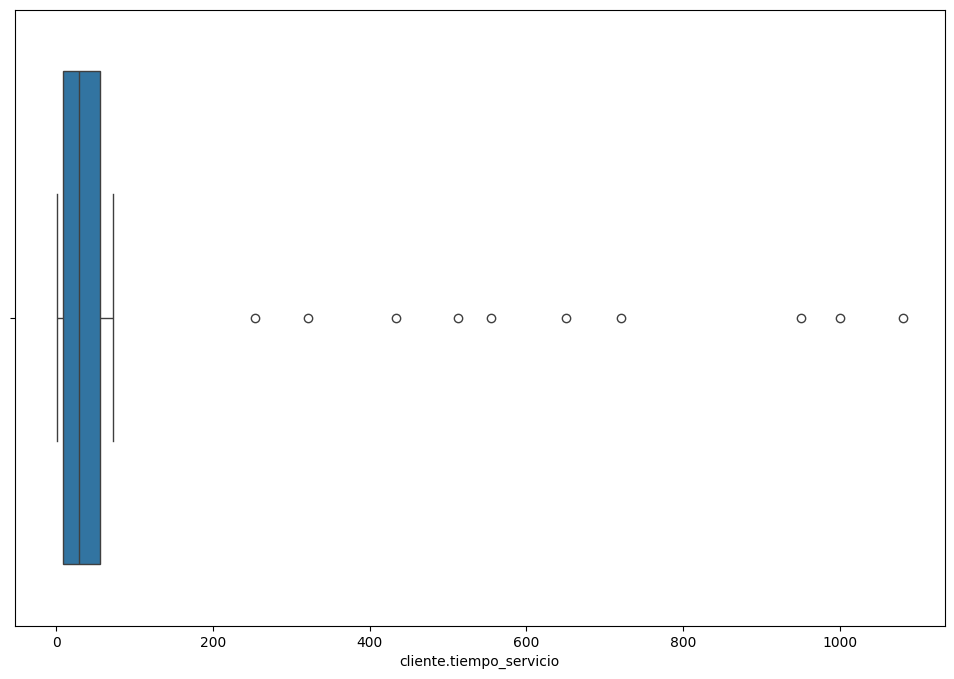

In [ ]:
plt.figure(figsize=(12,8))
sns.boxplot(x=df_sin_nulos["cliente.tiempo_servicio"])
plt.show

In [ ]:
q1= df_sin_nulos["cliente.tiempo_servicio"].quantile(0.25)
q3= df_sin_nulos["cliente.tiempo_servicio"].quantile(0.75)
iqr= q3-q1
iqr

np.float64(47.0)

In [ ]:
lim_inferior= q1-1.5*iqr
lim_superior= q3+1.5*iqr
df_sin_nulos[(df_sin_nulos["cliente.tiempo_servicio"] < lim_inferior) | (df_sin_nulos["cliente.tiempo_servicio"] > lim_superior)].shape[0]

10

In [ ]:
outliers= df_sin_nulos[(df_sin_nulos["cliente.tiempo_servicio"] < lim_inferior) | (df_sin_nulos["cliente.tiempo_servicio"] > lim_superior)]
outliers

,id_cliente,churn,cliente.genero,cliente.adulto_mayor,cliente.pareja,cliente.dependientes,cliente.tiempo_servicio,telefono.servicio_telefono,telefono.varias_lineas,internet.servicio_internet,internet.seguridad_online,internet.backup_online,internet.proteccion_dispositivo,internet.soporte_tecnico,internet.tv_streaming,internet.peliculas_streaming,cuenta.contrato,cuenta.factura_eletronica,cuenta.metodo_pago,cuenta.cobranza.mensual,cuenta.cobranza.total
1945,2830-LEWOA,no,masculino,0,sí,sí,1080.0,sí,no,fibra óptica,no,sí,sí,sí,sí,sí,un año,no,tarjeta de crédito (automático),103.90,112212.00
1946,2831-EBWRN,no,masculino,0,no,no,1000.0,sí,no,DSL,no,no,no,no,no,no,mensual,sí,cheque electrónico,45.90,45900.00
1952,2834-SPCJV,sí,masculino,0,sí,no,950.0,sí,no,fibra óptica,sí,no,no,no,sí,no,mensual,no,cheque electrónico,84.10,79895.00
1956,2842-JTCCU,sí,masculino,0,no,no,254.0,sí,no,DSL,no,no,no,no,no,no,mensual,no,transferencia bancaria (automática),46.05,80.35
1958,2845-AFFTX,sí,masculino,1,sí,no,321.0,sí,sí,fibra óptica,no,no,sí,no,sí,sí,mensual,sí,cheque electrónico,99.80,4259.30
1963,2851-STERV,no,masculino,1,no,no,650.0,sí,no,DSL,no,no,sí,sí,sí,sí,un año,sí,cheque electrónico,73.00,47450.00
1966,2856-NNASM,sí,masculino,1,no,no,721.0,sí,no,fibra óptica,no,no,no,no,sí,sí,mensual,sí,cheque vía correo,89.55,3856.75
1970,2862-JVEOY,no,masculino,0,no,no,555.0,sí,no,no,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,un año,no,cheque vía correo,19.15,124.40
1973,2865-TCHJW,sí,femenino,1,no,no,433.0,sí,sí,fibra óptica,no,no,sí,no,sí,no,mensual,sí,cheque electrónico,89.20,346.20
1974,2866-IKBTM,no,femenino,0,no,no,512.0,sí,no,no,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,sin servicio de internet,mensual,no,cheque vía correo,19.55,19.55


## 4.2 - Tratando los valores atípicos

In [ ]:
outliers[["cliente.tiempo_servicio", "cuenta.cobranza.mensual", "cuenta.cobranza.total"]]

,cliente.tiempo_servicio,cuenta.cobranza.mensual,cuenta.cobranza.total
1945,1080.0,103.90,112212.00
1946,1000.0,45.90,45900.00
1952,950.0,84.10,79895.00
1956,254.0,46.05,80.35
1958,321.0,99.80,4259.30
1963,650.0,73.00,47450.00
1966,721.0,89.55,3856.75
1970,555.0,19.15,124.40
1973,433.0,89.20,346.20
1974,512.0,19.55,19.55


In [ ]:
filtro= (df_sin_nulos["cliente.tiempo_servicio"] < lim_inferior) | (df_sin_nulos["cliente.tiempo_servicio"] > lim_superior)

In [ ]:
df_sin_outliers= df_sin_nulos.copy()
df_sin_outliers[filtro]["cliente.tiempo_servicio"]

,cliente.tiempo_servicio
1945,1080.0
1946,1000.0
1952,950.0
1956,254.0
1958,321.0
1963,650.0
1966,721.0
1970,555.0
1973,433.0
1974,512.0


In [ ]:
df_sin_outliers.loc[filtro, "cliente.tiempo_servicio"]= np.ceil(df_sin_outliers["cuenta.cobranza.total"]/df_sin_outliers["cuenta.cobranza.mensual"])

<function matplotlib.pyplot.show(close=None, block=None)>

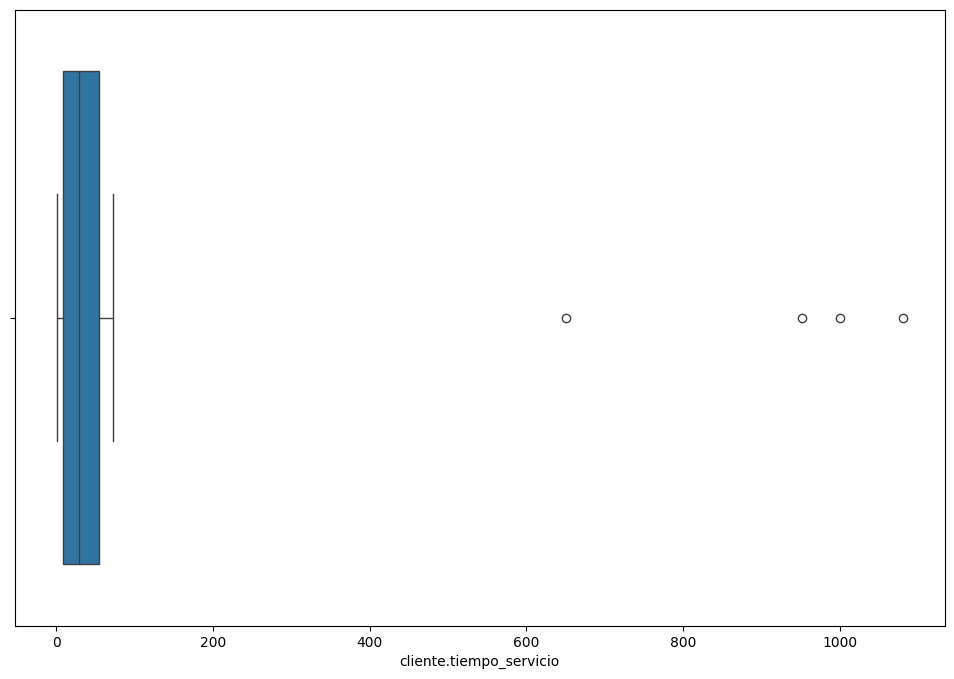

In [ ]:
plt.figure(figsize=(12,8))
sns.boxplot(x=df_sin_outliers["cliente.tiempo_servicio"])
plt.show

In [ ]:
q1= df_sin_outliers["cliente.tiempo_servicio"].quantile(0.25)
q3= df_sin_outliers["cliente.tiempo_servicio"].quantile(0.75)
iqr= q3-q1
lim_inferior= q1-1.5*iqr
lim_superior= q3+1.5*iqr
filtro= (df_sin_outliers["cliente.tiempo_servicio"] < lim_inferior) | (df_sin_outliers["cliente.tiempo_servicio"] > lim_superior)

In [ ]:
df_sin_outliers[filtro]["cliente.tiempo_servicio"]

,cliente.tiempo_servicio
1945,1080.0
1946,1000.0
1952,951.0
1963,650.0


## 4.3 - Removiendo los outliers

In [ ]:
df_sin_outliers[filtro]

,id_cliente,churn,cliente.genero,cliente.adulto_mayor,cliente.pareja,cliente.dependientes,cliente.tiempo_servicio,telefono.servicio_telefono,telefono.varias_lineas,internet.servicio_internet,internet.seguridad_online,internet.backup_online,internet.proteccion_dispositivo,internet.soporte_tecnico,internet.tv_streaming,internet.peliculas_streaming,cuenta.contrato,cuenta.factura_eletronica,cuenta.metodo_pago,cuenta.cobranza.mensual,cuenta.cobranza.total
1945,2830-LEWOA,no,masculino,0,sí,sí,1080.0,sí,no,fibra óptica,no,sí,sí,sí,sí,sí,un año,no,tarjeta de crédito (automático),103.9,112212.0
1946,2831-EBWRN,no,masculino,0,no,no,1000.0,sí,no,DSL,no,no,no,no,no,no,mensual,sí,cheque electrónico,45.9,45900.0
1952,2834-SPCJV,sí,masculino,0,sí,no,951.0,sí,no,fibra óptica,sí,no,no,no,sí,no,mensual,no,cheque electrónico,84.1,79895.0
1963,2851-STERV,no,masculino,1,no,no,650.0,sí,no,DSL,no,no,sí,sí,sí,sí,un año,sí,cheque electrónico,73.0,47450.0


In [ ]:
df= df_sin_outliers[~filtro].reset_index(drop=True)
df

,id_cliente,churn,cliente.genero,cliente.adulto_mayor,cliente.pareja,cliente.dependientes,cliente.tiempo_servicio,telefono.servicio_telefono,telefono.varias_lineas,internet.servicio_internet,internet.seguridad_online,internet.backup_online,internet.proteccion_dispositivo,internet.soporte_tecnico,internet.tv_streaming,internet.peliculas_streaming,cuenta.contrato,cuenta.factura_eletronica,cuenta.metodo_pago,cuenta.cobranza.mensual,cuenta.cobranza.total
0,0003-MKNFE,no,masculino,0,no,no,9.0,sí,sí,DSL,no,no,no,no,no,sí,mensual,no,cheque vía correo,59.90,542.40
1,0004-TLHLJ,sí,masculino,0,no,no,4.0,sí,no,fibra óptica,no,no,sí,no,no,no,mensual,sí,cheque electrónico,73.90,280.85
2,0011-IGKFF,sí,masculino,1,sí,no,13.0,sí,no,fibra óptica,no,sí,sí,no,sí,sí,mensual,sí,cheque electrónico,98.00,1237.85
3,0013-EXCHZ,sí,femenino,1,sí,no,3.0,sí,no,fibra óptica,no,no,no,sí,sí,no,mensual,sí,cheque vía correo,83.90,267.40
4,0013-MHZWF,no,femenino,0,no,sí,9.0,sí,no,DSL,no,no,no,sí,sí,sí,mensual,sí,tarjeta de crédito (automático),69.40,571.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6997,9987-LUTYD,no,femenino,0,no,no,13.0,sí,no,DSL,sí,no,no,sí,no,no,un año,no,cheque vía correo,55.15,742.90
6998,9992-RRAMN,sí,masculino,0,sí,no,22.0,sí,sí,fibra óptica,no,no,no,no,no,sí,mensual,sí,cheque electrónico,85.10,1873.70
6999,9992-UJOEL,no,masculino,0,no,no,2.0,sí,no,DSL,no,sí,no,no,no,no,mensual,sí,cheque vía correo,50.30,92.75
7000,9993-LHIEB,no,masculino,0,sí,sí,67.0,sí,no,DSL,sí,no,sí,sí,no,sí,dos años,no,cheque vía correo,67.85,4627.65


<function matplotlib.pyplot.show(close=None, block=None)>

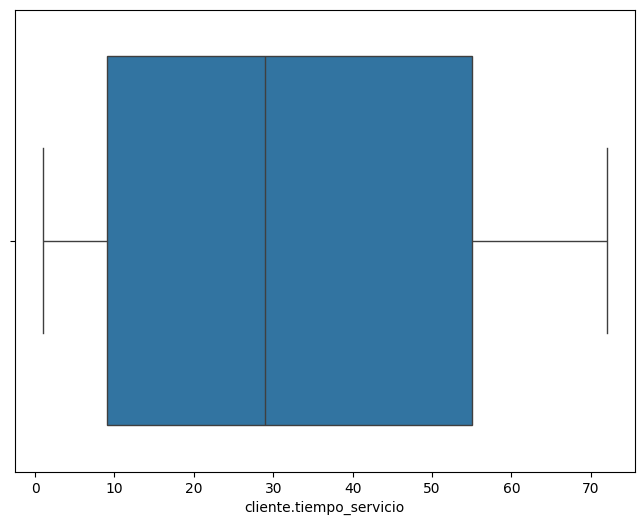

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df["cliente.tiempo_servicio"])
plt.show

## 5.1 - Sustituyendo las variables

In [ ]:
for col in df.columns:
  print(f"la columna: {col} contiene los siguientes valores:")
  print(df[col].unique())
  print("-"*50)

la columna: id_cliente contiene los siguientes valores:
['0003-MKNFE' '0004-TLHLJ' '0011-IGKFF' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
--------------------------------------------------
la columna: churn contiene los siguientes valores:
['no' 'sí']
--------------------------------------------------
la columna: cliente.genero contiene los siguientes valores:
['masculino' 'femenino']
--------------------------------------------------
la columna: cliente.adulto_mayor contiene los siguientes valores:
[0 1]
--------------------------------------------------
la columna: cliente.pareja contiene los siguientes valores:
['no' 'sí']
--------------------------------------------------
la columna: cliente.dependientes contiene los siguientes valores:
['no' 'sí']
--------------------------------------------------
la columna: cliente.tiempo_servicio contiene los siguientes valores:
[ 9.  4. 13.  3. 71. 63.  7. 66. 54. 72.  5. 56. 34.  1. 45. 50. 23. 55.
 26. 69. 37. 49. 67. 20. 43. 59. 12. 27. 

In [ ]:
df.drop("id_cliente", axis=1, inplace= True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7002 entries, 0 to 7001
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   churn                            7002 non-null   object 
 1   cliente.genero                   7002 non-null   object 
 2   cliente.adulto_mayor             7002 non-null   int64  
 3   cliente.pareja                   7002 non-null   object 
 4   cliente.dependientes             7002 non-null   object 
 5   cliente.tiempo_servicio          7002 non-null   float64
 6   telefono.servicio_telefono       7002 non-null   object 
 7   telefono.varias_lineas           7002 non-null   object 
 8   internet.servicio_internet       7002 non-null   object 
 9   internet.seguridad_online        7002 non-null   object 
 10  internet.backup_online           7002 non-null   object 
 11  internet.proteccion_dispositivo  7002 non-null   object 
 12  internet.soporte_tec

In [ ]:
columnas= ["churn", "cliente.genero", "cliente.pareja", "cliente.dependientes", "telefono.servicio_telefono", "cuenta.factura_eletronica"]
mapa= {"no":0, "sí":1, "masculino":0, "femenino":1}
df[columnas] = df[columnas].replace(mapa)
for col in df.columns:
  print(f"la columna: {col} contiene los siguientes valores:")
  print(df[col].unique())
  print("-"*50)

la columna: churn contiene los siguientes valores:
[0 1]
--------------------------------------------------
la columna: cliente.genero contiene los siguientes valores:
[0 1]
--------------------------------------------------
la columna: cliente.adulto_mayor contiene los siguientes valores:
[0 1]
--------------------------------------------------
la columna: cliente.pareja contiene los siguientes valores:
[0 1]
--------------------------------------------------
la columna: cliente.dependientes contiene los siguientes valores:
[0 1]
--------------------------------------------------
la columna: cliente.tiempo_servicio contiene los siguientes valores:
[ 9.  4. 13.  3. 71. 63.  7. 66. 54. 72.  5. 56. 34.  1. 45. 50. 23. 55.
 26. 69. 37. 49. 67. 20. 43. 59. 12. 27.  2. 25. 29. 14. 35. 64. 39. 40.
 11.  6. 30. 70. 57. 58. 16. 32. 33. 10. 21. 61. 15. 44. 22. 24. 19. 47.
 62. 46. 52.  8. 60. 48. 28. 41. 53. 68. 31. 36. 17. 18. 65. 51. 38. 42.]
--------------------------------------------------

/tmp/ipykernel_2139/969536852.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[columnas] = df[columnas].replace(mapa)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7002 entries, 0 to 7001
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   churn                            7002 non-null   int64  
 1   cliente.genero                   7002 non-null   int64  
 2   cliente.adulto_mayor             7002 non-null   int64  
 3   cliente.pareja                   7002 non-null   int64  
 4   cliente.dependientes             7002 non-null   int64  
 5   cliente.tiempo_servicio          7002 non-null   float64
 6   telefono.servicio_telefono       7002 non-null   int64  
 7   telefono.varias_lineas           7002 non-null   object 
 8   internet.servicio_internet       7002 non-null   object 
 9   internet.seguridad_online        7002 non-null   object 
 10  internet.backup_online           7002 non-null   object 
 11  internet.proteccion_dispositivo  7002 non-null   object 
 12  internet.soporte_tec

## 5.2 - One Hot Encoding

In [ ]:
s = pd.Series(list('abca'))
s

,0
0,a
1,b
2,c
3,d


In [ ]:
pd.get_dummies(s)

,a,b,c
0,True,False,False
1,False,True,False
2,False,False,True
3,True,False,False


In [ ]:
pd.get_dummies(s,dtype=int)

,a,b,c
0,1,0,0
1,0,1,0
2,0,0,1
3,1,0,0


In [ ]:
df_ml= pd.get_dummies(df,dtype=int)
df_ml

,churn,cliente.genero,cliente.adulto_mayor,cliente.pareja,cliente.dependientes,cliente.tiempo_servicio,telefono.servicio_telefono,cuenta.factura_eletronica,cuenta.cobranza.mensual,cuenta.cobranza.total,telefono.varias_lineas_no,telefono.varias_lineas_sin servicio de teléfono,telefono.varias_lineas_sí,internet.servicio_internet_DSL,internet.servicio_internet_fibra óptica,internet.servicio_internet_no,internet.seguridad_online_no,internet.seguridad_online_sin servicio de internet,internet.seguridad_online_sí,internet.backup_online_no,internet.backup_online_sin servicio de internet,internet.backup_online_sí,internet.proteccion_dispositivo_no,internet.proteccion_dispositivo_sin servicio de internet,internet.proteccion_dispositivo_sí,internet.soporte_tecnico_no,internet.soporte_tecnico_sin servicio de internet,internet.soporte_tecnico_sí,internet.tv_streaming_no,internet.tv_streaming_sin servicio de internet,internet.tv_streaming_sí,internet.peliculas_streaming_no,internet.peliculas_streaming_sin servicio de internet,internet.peliculas_streaming_sí,cuenta.contrato_dos años,cuenta.contrato_mensual,cuenta.contrato_un año,cuenta.metodo_pago_cheque electrónico,cuenta.metodo_pago_cheque vía correo,cuenta.metodo_pago_tarjeta de crédito (automático),cuenta.metodo_pago_transferencia bancaria (automática)
0,0,0,0,0,0,9.0,1,0,59.90,542.40,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0
1,1,0,0,0,0,4.0,1,1,73.90,280.85,1,0,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0
2,1,0,1,1,0,13.0,1,1,98.00,1237.85,1,0,0,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0
3,1,1,1,1,0,3.0,1,1,83.90,267.40,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,0,1,0,0,1,0,0
4,0,1,0,0,1,9.0,1,1,69.40,571.45,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6997,0,1,0,0,0,13.0,1,0,55.15,742.90,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,1,0,0
6998,1,0,0,1,0,22.0,1,1,85.10,1873.70,0,0,1,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0
6999,0,0,0,0,0,2.0,1,1,50.30,92.75,1,0,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0
7000,0,0,0,1,1,67.0,1,0,67.85,4627.65,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,1,0,0,0,1,0,0


In [ ]:
df_ml.shape

(7002, 41)

In [ ]:
df.shape

(7002, 20)

In [ ]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7002 entries, 0 to 7001
Data columns (total 41 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   churn                                                     7002 non-null   int64  
 1   cliente.genero                                            7002 non-null   int64  
 2   cliente.adulto_mayor                                      7002 non-null   int64  
 3   cliente.pareja                                            7002 non-null   int64  
 4   cliente.dependientes                                      7002 non-null   int64  
 5   cliente.tiempo_servicio                                   7002 non-null   float64
 6   telefono.servicio_telefono                                7002 non-null   int64  
 7   cuenta.factura_eletronica                                 7002 non-null   int64  
 8   cuenta.cobranza.me

In [ ]:
df_ml.to_csv("/content/datos_telecom_procesado.csv", sep=";", index=False)